<a href="https://colab.research.google.com/github/MelCrespo/ProcesosEstocasticos/blob/main/05_Teoria_de_Colas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Define simulation parameters
lambda_val = 8  # Arrival rate (customers per hour)
mu_val = 10      # Service rate (customers per hour)
num_customers = 10000 # Number of customers to simulate

def mm1_queue_simulation(lambda_val, mu_val, num_customers):
    # Generate inter-arrival times and service times
    inter_arrival_times = np.random.exponential(1 / lambda_val, num_customers)
    service_times = np.random.exponential(1 / mu_val, num_customers)

    arrival_times = np.cumsum(inter_arrival_times)

    # Initialize variables
    service_start_times = np.zeros(num_customers)
    departure_times = np.zeros(num_customers)
    waiting_times = np.zeros(num_customers)
    system_times = np.zeros(num_customers)

    # First customer
    service_start_times[0] = arrival_times[0]
    departure_times[0] = service_start_times[0] + service_times[0]
    waiting_times[0] = 0 # First customer doesn't wait
    system_times[0] = service_times[0]

    # Simulate for subsequent customers
    for i in range(1, num_customers):
        # Service starts either when the customer arrives or when the previous customer departs
        service_start_times[i] = max(arrival_times[i], departure_times[i-1])
        departure_times[i] = service_start_times[i] + service_times[i]

        waiting_times[i] = service_start_times[i] - arrival_times[i]
        system_times[i] = departure_times[i] - arrival_times[i]

    # Calculate performance metrics
    avg_waiting_time = np.mean(waiting_times)
    avg_system_time = np.mean(system_times)

    # Using Little's Law for average queue and system length
    avg_queue_length = lambda_val * avg_waiting_time
    avg_system_length = lambda_val * avg_system_time

    return avg_waiting_time, avg_system_time, avg_queue_length, avg_system_length, arrival_times, departure_times, service_start_times, waiting_times, system_times


# Run the simulation
avg_wait, avg_sys, avg_q_len, avg_sys_len, arrival_times, departure_times, service_start_times, all_waiting_times, all_system_times = mm1_queue_simulation(lambda_val, mu_val, num_customers)

print(f"Simulation Results for M/M/1 Queue (λ={lambda_val}, μ={mu_val}, N={num_customers}):")
print(f"Ocupación del sistema: {lambda_val/mu_val:.4f}")
print(f"Número promedio de clientes en el sistema (Average System Length): {avg_sys_len:.4f} clientes")
print(f"Número promedio de clientes en la cola (Average Queue Length): {avg_q_len:.4f} clientes")
print(f"Tiempo promedio en el sistema (Average System Time): {avg_sys:.4f} minutos")
print(f"Tiempo promedio en la cola (Average Waiting Time): {avg_wait:.4f} minutos")

Simulation Results for M/M/1 Queue (λ=8, μ=10, N=10000):
Ocupación del sistema: 0.8000
Número promedio de clientes en el sistema (Average System Length): 3.7985 clientes
Número promedio de clientes en la cola (Average Queue Length): 2.9894 clientes
Tiempo promedio en el sistema (Average System Time): 0.4748 minutos
Tiempo promedio en la cola (Average Waiting Time): 0.3737 minutos


### Distribución de Tiempos de Espera y Tiempos en el Sistema (Histogramas)

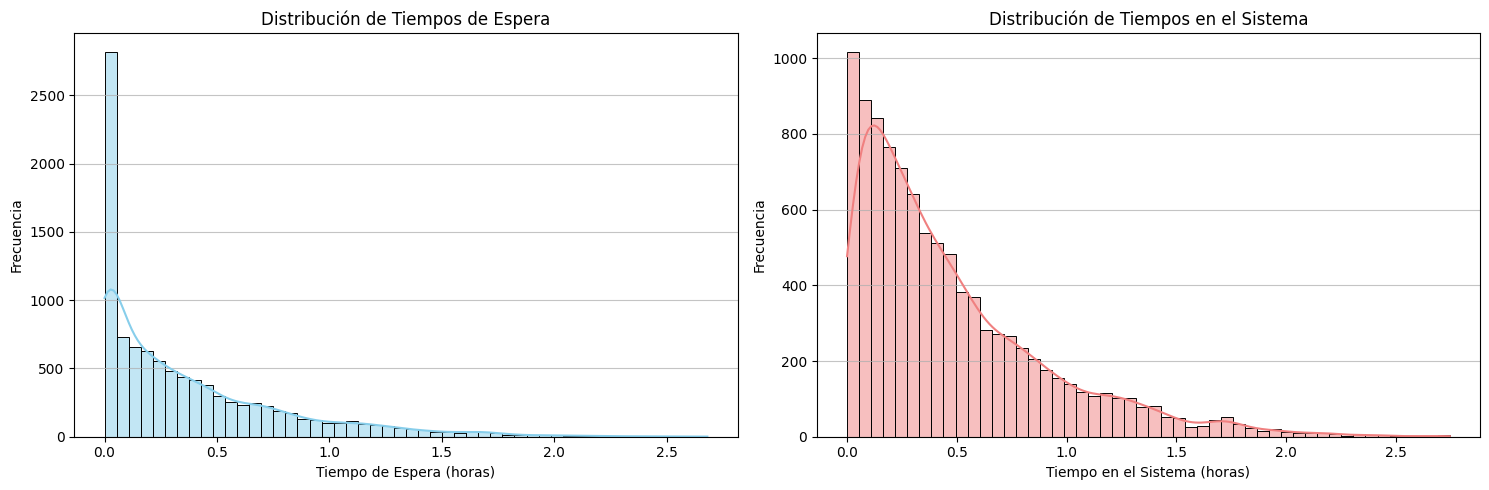

In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms of waiting times and system times
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(all_waiting_times, bins=50, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Tiempos de Espera')
axes[0].set_xlabel('Tiempo de Espera (horas)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.75)

sns.histplot(all_system_times, bins=50, kde=True, color='lightcoral', ax=axes[1])
axes[1].set_title('Distribución de Tiempos en el Sistema')
axes[1].set_xlabel('Tiempo en el Sistema (horas)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### Clientes en el Sistema y en la Cola a lo Largo del Tiempo

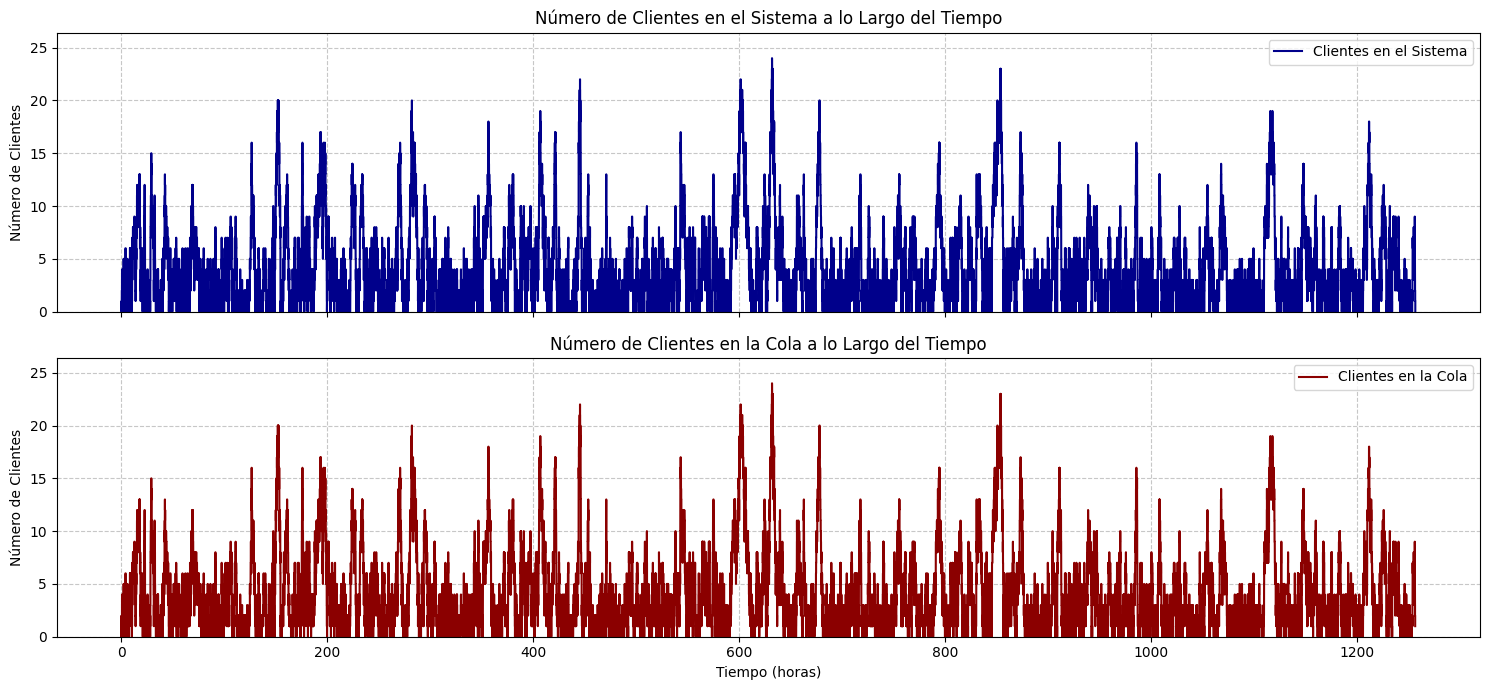

In [3]:
import matplotlib.pyplot as plt

# --- Calculations for Customers in System Over Time ---
# Combine arrival and departure events
event_times_sys = np.concatenate([arrival_times, departure_times])
event_types_sys = np.concatenate([np.ones_like(arrival_times), -np.ones_like(departure_times)]) # +1 for arrival, -1 for departure

# Sort events by time
sorted_indices_sys = np.argsort(event_times_sys)
sorted_event_times_sys = event_times_sys[sorted_indices_sys]
sorted_event_types_sys = event_types_sys[sorted_indices_sys]

customers_in_system_data = []
time_points_sys = []
current_customers_sys = 0

# Populate time_points and customer counts for plot
for t, event_type in zip(sorted_event_times_sys, sorted_event_types_sys):
    if not time_points_sys or t > time_points_sys[-1]:
        time_points_sys.append(t)
        customers_in_system_data.append(current_customers_sys)

    current_customers_sys += event_type
    time_points_sys.append(t)
    customers_in_system_data.append(current_customers_sys)

# Add the final state at the very last time point (if needed)
if time_points_sys[-1] < sorted_event_times_sys[-1]:
    time_points_sys.append(sorted_event_times_sys[-1])
    customers_in_system_data.append(current_customers_sys)

# --- Calculations for Customers in Queue Over Time ---
# Combine arrival events and service start events
# Customers enter queue on arrival, leave queue when service starts
event_times_queue = np.concatenate([arrival_times, service_start_times])
event_types_queue = np.concatenate([np.ones_like(arrival_times), -np.ones_like(service_start_times)]) # +1 for arrival, -1 for service start

# Sort events by time
sorted_indices_queue = np.argsort(event_times_queue)
sorted_event_times_queue = event_times_queue[sorted_indices_queue]
sorted_event_types_queue = event_types_queue[sorted_indices_queue]

customers_in_queue_data = []
time_points_queue = []
current_customers_queue = 0

# Populate time_points and customer counts for plot
for t, event_type in zip(sorted_event_times_queue, sorted_event_types_queue):
    if not time_points_queue or t > time_points_queue[-1]:
        time_points_queue.append(t)
        customers_in_queue_data.append(current_customers_queue)

    current_customers_queue += event_type
    # Ensure queue doesn't go below zero due to floating point inaccuracies or slight event order issues
    current_customers_queue = max(0, current_customers_queue)
    time_points_queue.append(t)
    customers_in_queue_data.append(current_customers_queue)

# Add the final state at the very last time point (if needed)
if time_points_queue[-1] < sorted_event_times_queue[-1]:
    time_points_queue.append(sorted_event_times_queue[-1])
    customers_in_queue_data.append(current_customers_queue)

# --- Plotting in subplots ---
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True) # Share x-axis for better comparison

# Plot customers in system on the first subplot
axes[0].plot(time_points_sys, customers_in_system_data, color='darkblue', linewidth=1.5, label='Clientes en el Sistema')
axes[0].set_title('Número de Clientes en el Sistema a lo Largo del Tiempo')
axes[0].set_ylabel('Número de Clientes')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_ylim(bottom=0, top=max(customers_in_system_data) * 1.1) # Dynamic y-limit
axes[0].legend()

# Plot customers in queue on the second subplot
axes[1].plot(time_points_queue, customers_in_queue_data, color='darkred', linewidth=1.5, label='Clientes en la Cola')
axes[1].set_title('Número de Clientes en la Cola a lo Largo del Tiempo')
axes[1].set_xlabel('Tiempo (horas)')
axes[1].set_ylabel('Número de Clientes')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_ylim(bottom=0, top=max(customers_in_queue_data) * 1.1) # Dynamic y-limit
axes[1].legend()

plt.tight_layout()
plt.show()